## 02. Machine Learning for Regression

In [2274]:
import pandas as pd 
import numpy as np

#### 2.2 Data Preparation

In [2275]:
df = pd.read_csv('data.csv')
df.head(7)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
5,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,31200
6,BMW,1 Series,2012,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,26,17,3916,44100


First of all, we can make a the columns' name consistent, such as, make them lower case, replace space with under score .e.t.c

In [2276]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [2277]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [2278]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Newt, we should find the 'string' columns:

In [2279]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [2280]:
# in pandas version >3.X, we use 'str' instead of 'object'
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [2281]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [2282]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### 2.3 Exploratory Data Analysis

In [2283]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print('--------')

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48
--------
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914
--------
year
[2011 2012 2013 1992 1993]
28
--------
engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10
--------
engine_hp
[335. 300. 230. 320. 172.]
356
--------
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
--------
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5
--------
driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4
--------
number_of_doors
[ 2.  4.  3. nan]
3
--------
market_category
<StringArray>
['factory_tuner,luxury,high-performance',


##### Distribution of price

In [2284]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

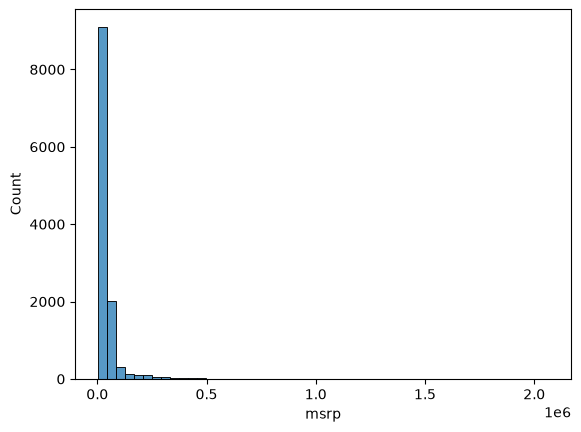

In [2285]:
sns.histplot(df.msrp, bins = 50) #bins = How many bars in the plot

this is called 'Long Tailed distribution', which the tail may confuse the ML model

<Axes: xlabel='msrp', ylabel='Count'>

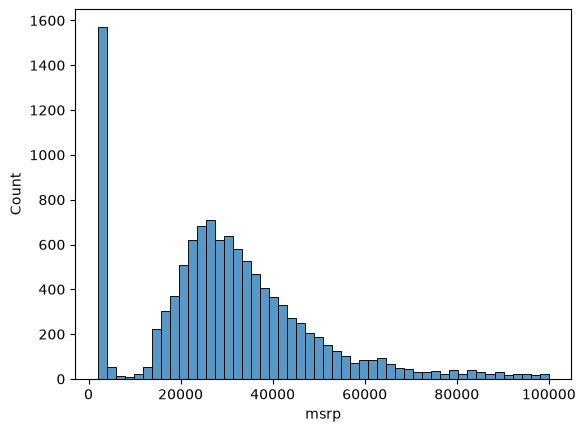

In [2286]:
sns.histplot(df.msrp[df.msrp < 100000], bins = 50) #bins = How many bars in the plot

So how do we deal with those long tails?

One solution is using logarithm, such as `np.log`. But if we encounter a zero-value, `np.log` would return an error. Thus `+1` to all the values before applying `np.log` is the way, or use `np.log1p` instead.

In [2287]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [2288]:
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [2289]:
##
prices_log = np.log1p(df.msrp)
print(prices_log)

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64


<Axes: xlabel='msrp', ylabel='Count'>

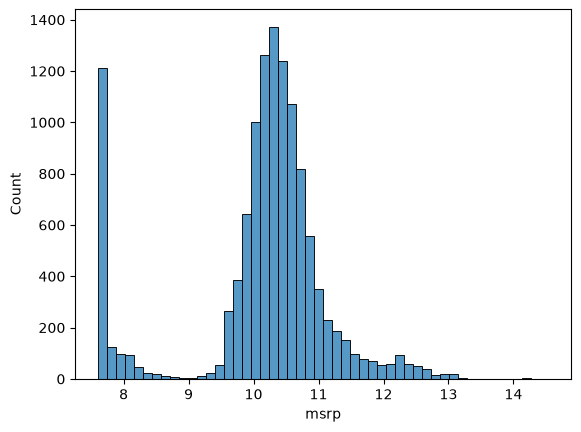

In [2290]:
sns.histplot(prices_log, bins = 50)

we can see that the tail is gone.

P.S. if your model's distribution is approximate to normal distribution, it is very ideal to ML 

##### Missing Values

In [2291]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### 2.4 Setting Up The Validation Framework

Here, we set `train`, `val`, `test` in 60 : 20 : 20 split

Let's draw it

In [2292]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_test - n_val # in order to avoid rounding error
print(n_val, n_test, n_train)

2382 2382 7150


In [2293]:
n, n_val + n_test + n_train

(11914, 11914)

In [2294]:
df_train = df.iloc[n_train:]
df_val = df.iloc[n_train:n_train + n_val]
df_test = df.iloc[n_train + n_val:]

df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,22,17,1385,37380
9528,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,extended_cab_pickup,23,16,1385,40100
9529,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42560
9530,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42860


Note: the splits above may have a problem, we didn't shuffle `df` before we split. it is because a dataset may have orders in it

How do we fix it?

In [2295]:
idx = np.arange(n)

In [2296]:
np.random.seed(2)
np.random.shuffle(idx)
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [2297]:
df.iloc[idx[:10]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
8001,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873,17575
2882,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520,191400
649,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916,76100
616,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67,379050
4459,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657,26030


In [2298]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
df_train.head(10)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
8001,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873,17575
2882,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520,191400
649,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916,76100
616,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67,379050
4459,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657,26030


In [2299]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

Now we reset each splits' index:

In [2300]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)
df_train.head(10)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
5,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873,17575
6,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520,191400
7,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916,76100
8,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67,379050
9,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657,26030


assign `y`s:

In [2301]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [2302]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [2303]:
len(y_train)

7150

### 2.5 Linear Regression

In [2304]:
df_train.iloc[10] # Note, we deleted the column: 'msrp'

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

### 2.6 Linear Regression vector form

In [2305]:
def dot(xi, w):
    n = len(xi)
    
    res = 0.0 # result, not residual XD
    
    for j in range(n):
        res = res + xi[j] * w[j]
        
    return res

In [2306]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [2307]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [2308]:
x1 = [1, 33, 45, 23]
x2 = [1, 56, 78, 34]
x3 = [1, 44, 76, 95]
w_new = [w0] + w
X = [x1, x2, x3]
X = np.array(X)
def linear_regression(X, W):
    return X.dot(W)
linear_regression(X, w_new)

array([ 9.346, 10.918, 10.84 ])

### 2.7 Training a linear regression model

In [2309]:
def train_linear_regression(X, y):
    pass

In [2310]:
X = [
    [145, 234, 665],
    [345, 786, 776],
    [432, 635, 86],
    [145, 234, 665],
    [315, 781, 476],
    [422, 632, 36],
    [145, 234, 65],
    [325, 711, 416],
    [432, 62, 336],
]
X = np.array(X)

y = [100, 200, 150, 234, 234, 123, 456, 479, 678]

In [2311]:
# add a column of ones in X:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [2312]:
np.column_stack([ones, ones])
# therefore
X = np.column_stack([ones, X])
X

array([[  1., 145., 234., 665.],
       [  1., 345., 786., 776.],
       [  1., 432., 635.,  86.],
       [  1., 145., 234., 665.],
       [  1., 315., 781., 476.],
       [  1., 422., 632.,  36.],
       [  1., 145., 234.,  65.],
       [  1., 325., 711., 416.],
       [  1., 432.,  62., 336.]])

In [2313]:
XTX = X.T.dot(X)

In [2314]:
XTX_inv = np.linalg.inv(XTX)

In [2315]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.,  0.],
       [ 0.,  1., -0., -0.],
       [ 0.,  0.,  1., -0.],
       [ 0.,  0.,  0.,  1.]])

In [2316]:
w_full = XTX_inv.dot(X.T).dot(y)
w = w_full[1:]
w0 = w_full[0]

In [2317]:
w0, w

(np.float64(317.36293475025263),
 array([ 0.58975978, -0.40909875, -0.01003972]))

In [2318]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [2319]:
X = [
    [145, 234, 665],
    [345, 786, 776],
    [432, 635, 86],
    [145, 234, 665],
    [315, 781, 476],
    [422, 632, 36],
    [145, 234, 65],
    [325, 711, 416],
    [432, 62, 336],
]
X = np.array(X)

y = [100, 200, 150, 234, 234, 123, 456, 479, 678]
w0, w = train_linear_regression(X, y)

### 2.8 Car price baseline model

In [2320]:
df_train.dtypes != 'str'

make                 False
model                False
year                  True
engine_fuel_type     False
engine_hp             True
engine_cylinders      True
transmission_type    False
driven_wheels        False
number_of_doors       True
market_category      False
vehicle_size         False
vehicle_style        False
highway_mpg           True
city_mpg              True
popularity            True
dtype: bool

In [2321]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
base

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [2322]:
X_train = df_train[base].fillna(0).values # note that fill in missing values with zero is not always optimal

In [2323]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [2324]:
w0, w = train_linear_regression(X_train, y_train)

In [2325]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

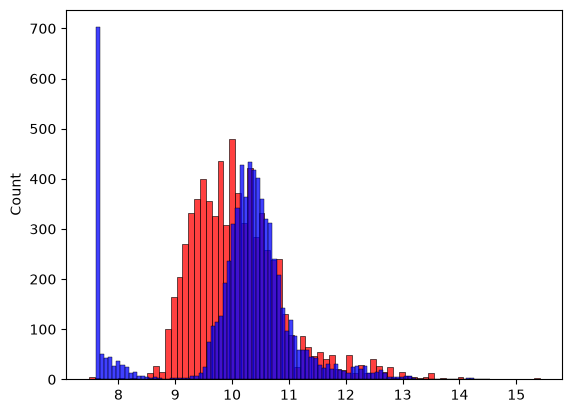

In [2326]:
sns.histplot(y_pred, color='red')
sns.histplot(y_train, color = 'blue')

### 2.9 RMSE

In [2327]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [2328]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

### 2.10 Validating the Model

In [2329]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [2330]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.7616530991301578)

### 2.11 Simple feature engineering

In [2331]:
# compute how old the cars are
df_train.year.max()

np.int64(2017)

In [2332]:
def prepare_X(df):
    df = df.copy() # in order to avoid modifying the origin dataset
    df['age'] = 2017 - df.year
    features = base + ['age']
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [2333]:
X_train = prepare_X(df_train)
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [2334]:
X_train[1]

array([ 132.,    4.,   32.,   25., 2031.,    5.])

In [2335]:
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5172055461058329)

RMSE decreased, which is an improvement

<Axes: ylabel='Count'>

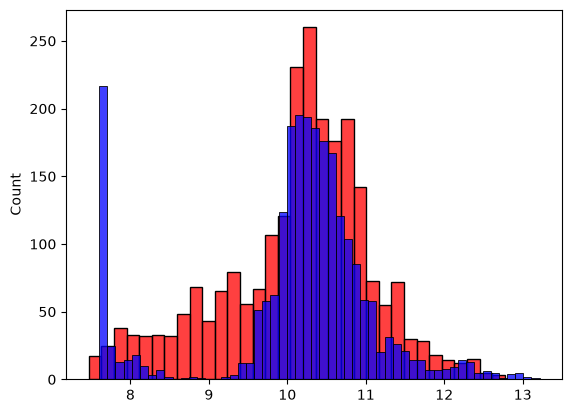

In [2336]:
sns.histplot(y_pred, color='red')
sns.histplot(y_val, color = 'blue')

### 2.12 Categorical Variables

In [2337]:
(df_train.number_of_doors == 2).astype('int')

0       1
1       0
2       0
3       0
4       0
       ..
7145    1
7146    1
7147    0
7148    0
7149    0
Name: number_of_doors, Length: 7150, dtype: int64

In [2338]:
#for v in [2, 3, 4]:
#    df_train[f'number_doors_{v}'] = (df_train.number_of_doors == v).astype('int')


In [2339]:

df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86


In [2340]:
def prepare_X(df):
    df = df.copy() # in order to avoid modifying the origin dataset
    df['age'] = 2017 - df.year
    features = base + ['age']
    for v in [2, 3, 4]:
        df[f'number_doors_{v}'] = (df.number_of_doors == v).astype('int')
        features.append(f'number_doors_{v}')

    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [2341]:
prepare_X(df_train)

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   1.],
       [563.,  12.,  21., ...,   0.,   0.,   1.],
       [200.,   4.,  31., ...,   0.,   0.,   1.]], shape=(7150, 9))

In [2342]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5157995641502547)

In [2343]:
makes = list(df.make.value_counts().head().index) # top 5 most popular makes
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [2344]:
def prepare_X(df):
    df = df.copy() # in order to avoid modifying the origin dataset
    features = base.copy()
    df['age'] = 2017 - df.year
    features.append('age')
    for v in [2, 3, 4]:
        df[f'number_doors_{v}'] = (df.number_of_doors == v).astype('int')
        features.append(f'number_doors_{v}')
    
    for k in makes:
        df[f'make_{k}'] = (df.make == k).astype('int')
        features.append(f'make_{k}')

    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [2345]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5076038849556436)

In [2346]:
categories_list = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'
]

In [2347]:
categories_dict = {}

for c in categories_list:
    categories_dict[c] = list(df[c].value_counts().head().index)

In [2348]:
categories_dict

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [2349]:
def prepare_X(df):
    df = df.copy() # in order to avoid modifying the origin dataset
    features = base.copy()
    df['age'] = 2017 - df.year
    features.append('age')
    for v in [2, 3, 4]:
        df[f'number_doors_{v}'] = (df.number_of_doors == v).astype('int')
        features.append(f'number_doors_{v}')
    
    for k, values in categories_dict.items():
        for v in values:
            df[f'{k}_{v}'] = (df[k] == v).astype('int')
            features.append(f'{k}_{v}')

    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [2350]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(207.72734843256842)

In [2351]:
w0

np.float64(-6.415085869335294e+16)

### 2.13 Regularization

### Near-Duplicate Features, Matrix Inversion, and Regularization

In linear regression using the normal equation:

$$
w = (X^TX)^{-1}X^Ty
$$

a problem can occur when some columns in `X` are duplicate or nearly duplicate.

For example:

```text
x2 ≈ x1
```

This creates strong multicollinearity and makes:
$$
X^TX
$$
singular or nearly singular.
When we try to compute:
np.linalg.inv(X.T @ X)


the inverse becomes numerically unstable.
As a result:
- regression coefficients can become extremely large
- tiny floating-point differences can be greatly amplified
- predictions can change dramatically
- RMSE may jump from a reasonable value to something very large
This explains why the same model can sometimes produce very different RMSE values such as:
40
207
266

The issue is not that RMSE itself is random.
The problem is that the matrix inversion is unstable.
A useful diagnostic is the condition number:

```
np.linalg.cond(X.T @ X)
```

A very large condition number means the matrix is ill-conditioned and sensitive to small numerical errors.
Regularization
Ridge regularization improves stability by adding a small value to the diagonal:

$$
X^TX \rightarrow X^TX + \lambda I
$$

For example:
XTX = X.T @ X
XTX = XTX + r * np.eye(XTX.shape[0])


This makes the matrix easier and safer to invert.
Key Idea
duplicate / near-duplicate features
        ↓
multicollinearity
        ↓
XᵀX becomes nearly singular
        ↓
matrix inverse becomes unstable
        ↓
very large coefficients
        ↓
unstable predictions
        ↓
RMSE can change dramatically

Regularization helps stabilize the solution.

In [2352]:
def train_linear_regression_reg(X, y, r = 0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [2353]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, 0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4565219901362482)

Note that `r` is a parameter to be tuned.

### 2.14 Tunning the model

Using the validation set to find the best value of `r`

In [2354]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r = r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    print(r, w0, score)

0.0 -6.415085869335294e+16 207.72734843256842
1e-05 4.619594465378434 0.45651702820745765
0.0001 6.288488046926197 0.45651706378680923
0.001 6.285849878213023 0.45651750859090384
0.1 6.191208655410677 0.45656927630210653
1 5.634896667644497 0.45722043179974536
10 4.283980108964638 0.470145693210162


In [2355]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r = r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

score = rmse(y_val, y_pred)
print(r, w0, score)

0.001 6.285849878213023 0.45651750859090384


### 2.15 Using the model

After the all hyper parameters are decided, we can combine train and validation split into a bigger train dataset for the final training.

In [2356]:
df_full_train = pd.concat([df_train, df_val])
df_full_train.reset_index(drop = True)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436


In [2357]:
X_full_train = prepare_X(df_full_train)
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

----

In [2358]:
y_full_train = np.concatenate([y_train, y_val])

In [2359]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, 0.001)
w0

np.float64(6.322663304513474)

In [2360]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)
print(r, w0, score)

0.001 6.322663304513474 0.45177493056990925


In [ ]:
car = df_test.iloc[20].to_dict()
car # pretend this is the case from a user

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [2363]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [2364]:
X_small = prepare_X(df_small)
y_pred = w0 + X_small.dot(w)
y_pred

array([10.46265172])

In [ ]:
np.expm1(y_pred) # reverse log transformation

array([34983.19696713])

In [ ]:
np.expm1(y_test[20]) # compare the true y

np.float64(35000.00000000001)

## 2.16 Summary

- EDA: looking at data, finding missing values
- Target variable distribution -- long tail => bell shaped curve
- Validation framework: Train / val / test split (help us detect problems)
- Normal equation - not magic, but math
- Implemented it with NumPy
- RMSE to validate our model
- Feature engineering: age, categorical features
- Regularization to fight numerical instability

----

# Traditional Statistical Linear Regression — Quick Summary

## 1. Goal

Traditional statistical regression is mainly concerned with **inference**:

- How is `X` associated with `Y`?
- Is the relationship statistically significant?
- What is the estimated effect size?
- How uncertain is the estimate?
- Can we construct confidence intervals or perform hypothesis tests?

A basic linear regression model is:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \varepsilon
$$

where:

- `Y`: dependent / response variable
- `X`: independent / predictor variables
- `β`: regression coefficients
- `ε`: error term

## 2. Main Assumptions

### Linearity

The expected value of `Y` should be approximately a linear function of the predictors.

$$
E(Y|X) = \beta_0 + \beta_1X_1 + \cdots
$$

Check with:
- scatter plots
- residual vs fitted-value plots

### Independence

Observations / errors should be reasonably independent.

This is especially important for:
- time-series data
- repeated measurements
- clustered data

### Homoscedasticity

The variance of the errors should be approximately constant across fitted values.

Desired pattern:

```text
Residual spread:

 |   .  . .
 | . . . . .
0|------------
 | . . . . .
 |   .  .
```

Problematic funnel pattern:

```text
 |
 |       . .
 |     . . .
 |   . . . .
0|------------
 |   . . . .
 |     . . .
 |       . .
```

Possible responses include:
- transforming `Y` (e.g. log transformation)
- using heteroscedasticity-robust standard errors
- changing the model specification

### Normality of Errors

`X` and `Y` themselves do **not** need to follow a normal distribution.

For classical inference, the important assumption is approximately:

$$
\varepsilon | X \sim N(0, \sigma^2)
$$

Normal residuals are especially relevant for:
- p-values
- confidence intervals
- hypothesis tests

Check using:
- histogram of residuals
- Q-Q plot
- normality tests such as Shapiro-Wilk

For large datasets, visual diagnostics such as Q-Q plots are often more useful than relying only on normality-test p-values.

## 3. Residuals

After fitting the model:

$$
e_i = y_i - \hat{y}_i
$$

In Python:

```python
y_pred = model.predict(X)
residuals = y - y_pred
```

Ideally, residuals should:
- be centered around zero
- show no systematic pattern
- have approximately constant variance
- be reasonably symmetric / normal when classical inference is required

## 4. Transformations

Transformations are usually applied to `X` or `Y`, not directly to residuals.

### Log-transforming Y

Useful when `Y` is strongly right-skewed:

```python
y_log = np.log1p(y)
```

This may improve:
- linearity
- residual symmetry
- variance stability

### Transforming X

Useful when the relationship between `X` and `Y` is nonlinear.

Examples:

```python
np.log1p(x)
x ** 2
np.sqrt(x)
```

The purpose is not simply to make `X` normally distributed.

The purpose is usually to improve the relationship between predictors and the response.

## 5. Multicollinearity

Predictors should not contain excessive redundant information.

For example:

```text
X1 ≈ X2
```

can make regression coefficients unstable.

Possible diagnostics:
- correlation matrix
- Variance Inflation Factor (VIF)

Multicollinearity mainly affects interpretation and coefficient uncertainty rather than necessarily destroying predictive performance.

## 6. Outliers and Influential Observations

Outliers can have a large effect on OLS regression.

Useful diagnostics include:
- standardized residuals
- leverage
- Cook's distance

An outlier should not automatically be deleted; first determine whether it represents:
- a data error
- a rare but legitimate observation
- a sign that the model is misspecified

## 7. Statistical Inference

Traditional regression often focuses on coefficients such as:

$$
\hat{\beta}_1
$$

and asks questions such as:

```text
Is β₁ different from zero?
How large is the estimated effect?
What is its 95% confidence interval?
```

Typical outputs therefore include:
- coefficient estimates
- standard errors
- t-statistics
- p-values
- confidence intervals
- R² / adjusted R²

# Traditional Statistics vs Machine Learning

| Traditional Statistics | Machine Learning |
|---|---|
| Main goal: inference / explanation | Main goal: prediction / generalization |
| Strong interest in coefficients | Strong interest in validation performance |
| Model assumptions are important | Predictive performance may matter more than strict assumptions |
| p-values and confidence intervals are common | Metrics such as RMSE, MAE, AUC are common |
| Often emphasizes interpretable models | Can use highly complex models |
| Residual diagnostics are important | Train/validation/test evaluation is central |
| "What is the effect of X?" | "How accurately can we predict Y?" |

## Example

### Statistical question

> Holding other variables constant, how much does house price change when floor area increases by one unit?

Focus:

```text
coefficient
standard error
confidence interval
p-value
```

### Machine-learning question

> Given information about a house, how accurately can we predict its price for unseen houses?

Focus:

```text
train error
validation error
test error
RMSE / MAE
generalization
```

## Key Mental Model

Traditional statistics:

```text
Data
→ Fit model
→ Check assumptions
→ Estimate effects
→ Quantify uncertainty
→ Draw conclusions
```

Machine learning:

```text
Data
→ Train
→ Validate / tune
→ Test
→ Measure generalization
→ Deploy / predict
```

The methods can overlap heavily.

For example, linear regression can be used in both statistics and machine learning.

The main difference is often not the algorithm itself, but **what question we are trying to answer**.
